# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami pola, distribusi, hubungan antar variabel, serta karakteristik data sebelum masuk ke tahap preprocessing dan modeling.

# 1. Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
import scipy.stats as stats

# 2. Load Dataset

In [2]:
# membaca dataset hasil wrangling
df = pd.read_csv('../data/wrangled_data.csv')

In [3]:
# menampilkan 5 data pertama
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2021-01-01,store_1,item_1,36,21.3,0,4,1
1,2021-01-02,store_1,item_1,36,21.3,0,5,1
2,2021-01-03,store_1,item_1,35,21.3,0,6,1
3,2021-01-04,store_1,item_1,41,21.3,0,0,1
4,2021-01-05,store_1,item_1,53,21.3,0,1,1


# 3. Business Understanding
Pada tahap ini ditentukan beberapa pertanyaan bisnis yang akan dijawab melalui proses exploratory data analysis (EDA).

### Pertanyaan Bisnis

1. Bagaimana distribusi penjualan harian pada dataset store selama periode 2021 hingga 2023?

2. Produk apa yang memiliki jumlah penjualan tertinggi dan terendah selama periode 2021 hingga 2023?

3. Bagaimana hubungan antara harga produk dan jumlah penjualan selama periode 2021 hingga 2023?

4. Apakah terdapat pola penjualan tertentu berdasarkan waktu selama periode 2021 hingga 2023?

5. Variabel apa yang memiliki korelasi paling kuat terhadap penjualan selama periode 2021 hingga 2023?

6. Apakah terdapat outlier pada data penjualan selama periode 2021 hingga 2023 yang dapat mempengaruhi analisis?

# 4. Univariate Analysis

In [4]:
# statistik deskriptif
df.describe()

,sales,price,promo,weekday,month
count,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,29.877881,56.077581,0.099233,3.005479,6.526027
std,14.689005,24.102496,0.298977,2.000467,3.447883
min,0.000000,12.200000,0.000000,0.000000,1.000000
25%,19.000000,37.620000,0.000000,1.000000,4.000000
50%,28.000000,58.620000,0.000000,3.000000,7.000000
75%,39.000000,76.300000,0.000000,5.000000,10.000000
max,114.000000,99.990000,1.000000,6.000000,12.000000


In [5]:
# memilih kolom numerik
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

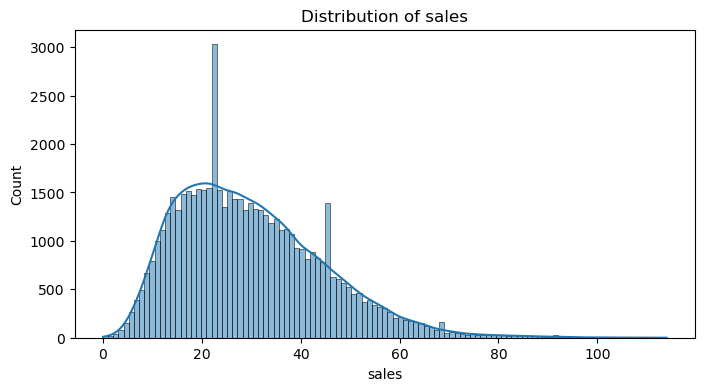

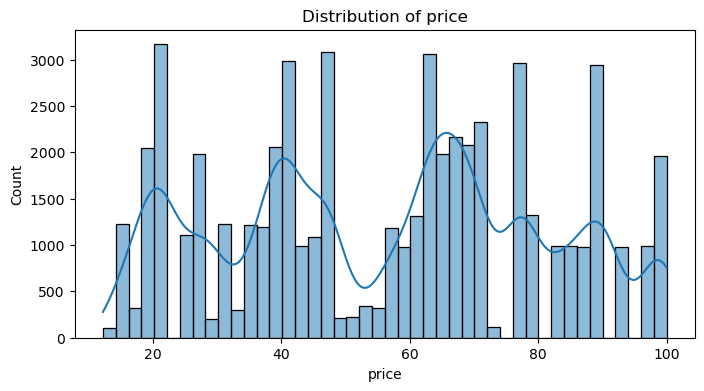

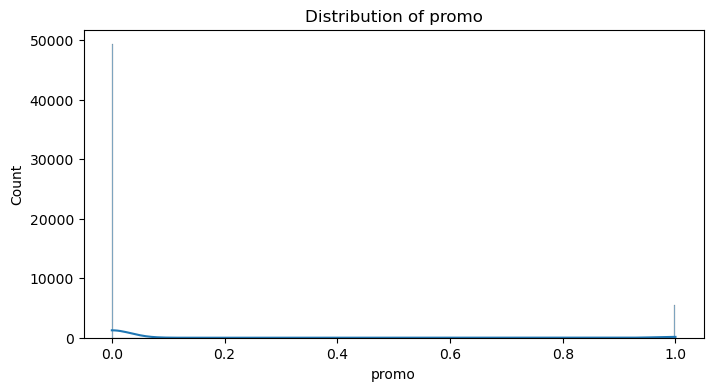

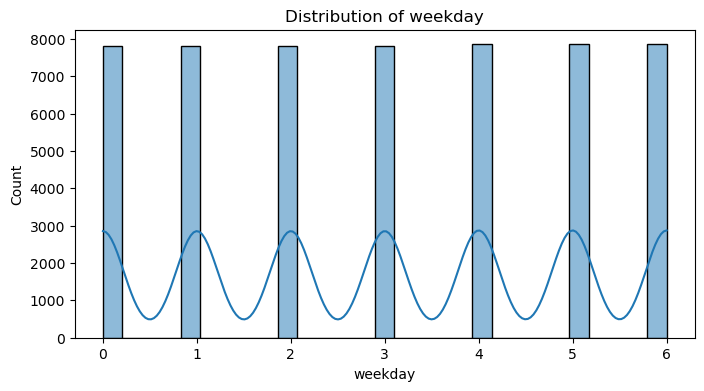

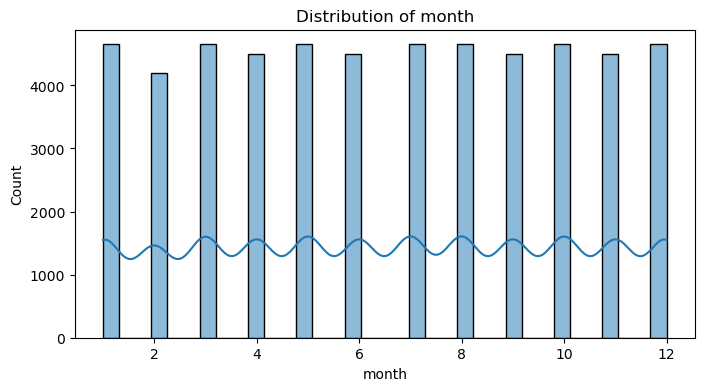

In [6]:
# visualisasi distribusi data numerik
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f'Distribution of {col}')
    
    plt.show()

In [7]:
# menghitung skewness
df[num_cols].skew().sort_values(ascending=False)

promo      2.681019
sales      0.812499
price      0.014459
weekday   -0.004111
month     -0.010457
dtype: float64

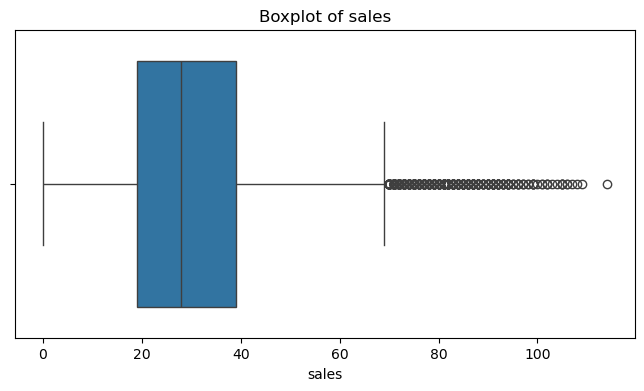

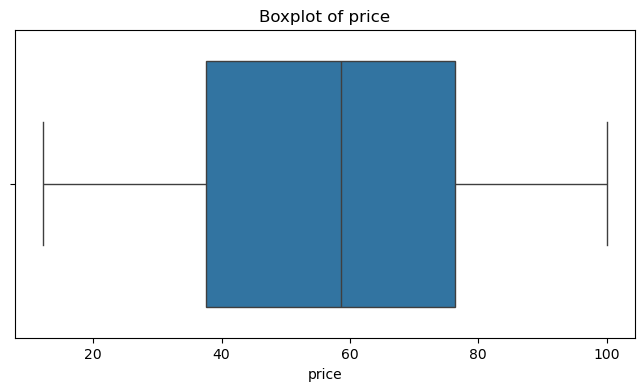

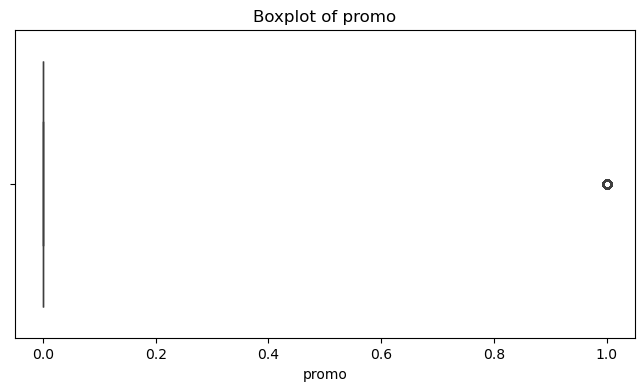

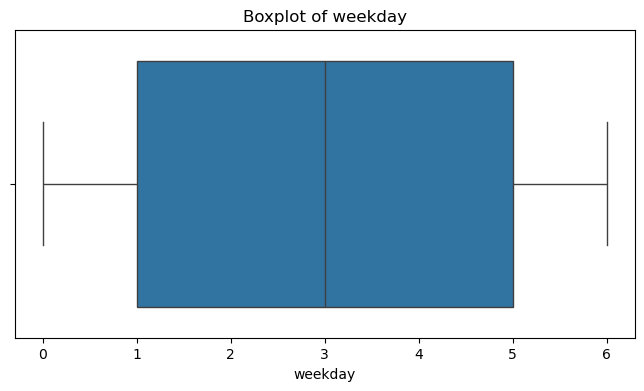

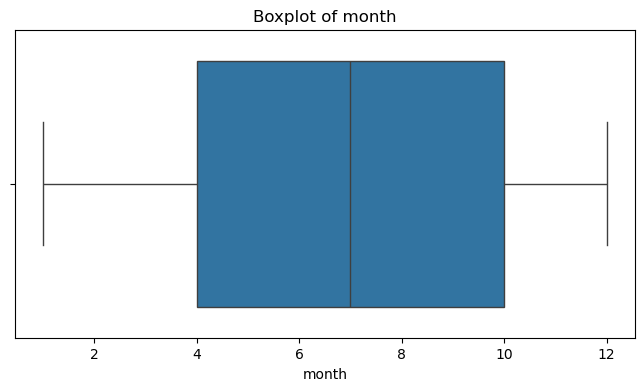

In [8]:
# boxplot numerical features
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

# 5. Categorical Analysis

In [9]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['date', 'store_id', 'item_id'], dtype='object')

In [10]:
# frequency analysis
for col in cat_cols:
    
    print(df[col].value_counts())
    print('-'*50)

date
2021-01-01    50
2022-12-30    50
2023-01-05    50
2023-01-04    50
2023-01-03    50
              ..
2022-01-07    50
2022-01-08    50
2022-01-09    50
2022-01-10    50
2023-12-31    50
Name: count, Length: 1095, dtype: int64
--------------------------------------------------
store_id
store_1    54750
Name: count, dtype: int64
--------------------------------------------------
item_id
item_1     1095
item_38    1095
item_28    1095
item_29    1095
item_30    1095
item_31    1095
item_32    1095
item_33    1095
item_34    1095
item_35    1095
item_36    1095
item_37    1095
item_39    1095
item_2     1095
item_40    1095
item_41    1095
item_42    1095
item_43    1095
item_44    1095
item_45    1095
item_46    1095
item_47    1095
item_48    1095
item_49    1095
item_27    1095
item_26    1095
item_25    1095
item_24    1095
item_3     1095
item_4     1095
item_5     1095
item_6     1095
item_7     1095
item_8     1095
item_9     1095
item_10    1095
item_11    1095
item_12    109

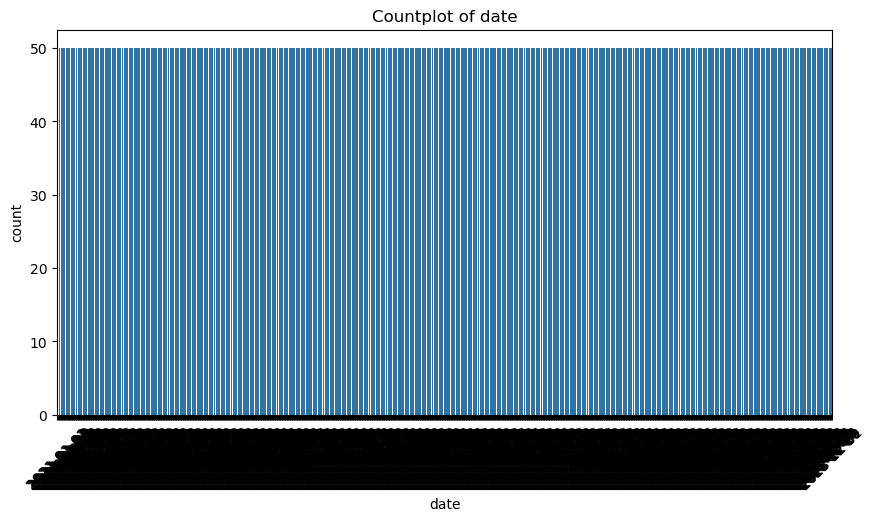

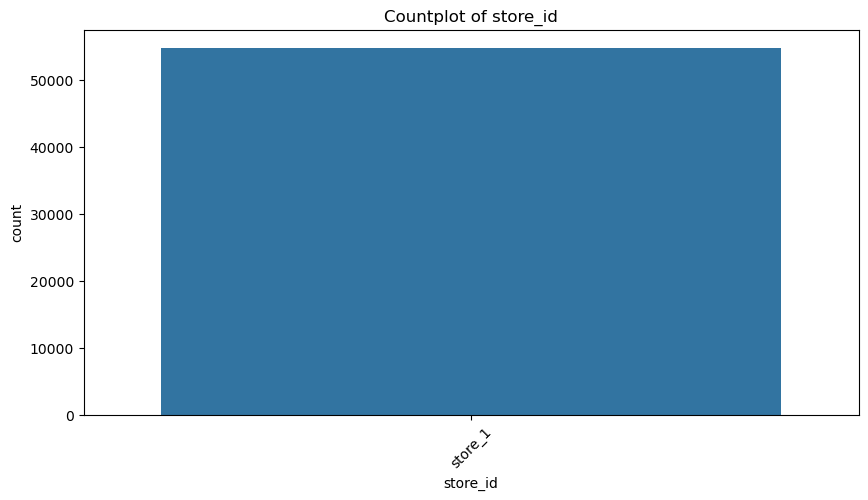

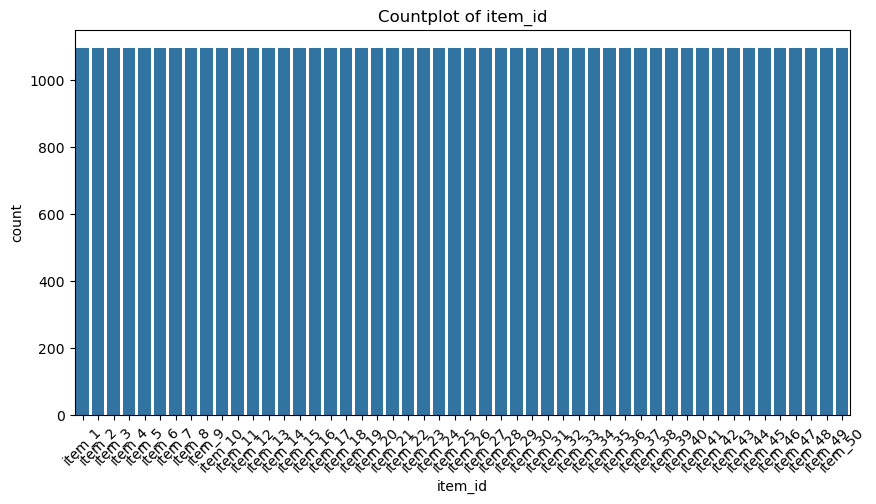

In [11]:
# visualisasi categorical features
for col in cat_cols:
    
    plt.figure(figsize=(10,5))
    
    sns.countplot(data=df, x=col)
    
    plt.xticks(rotation=45)
    
    plt.title(f'Countplot of {col}')
    
    plt.show()

# 6. Bivariate Analysis

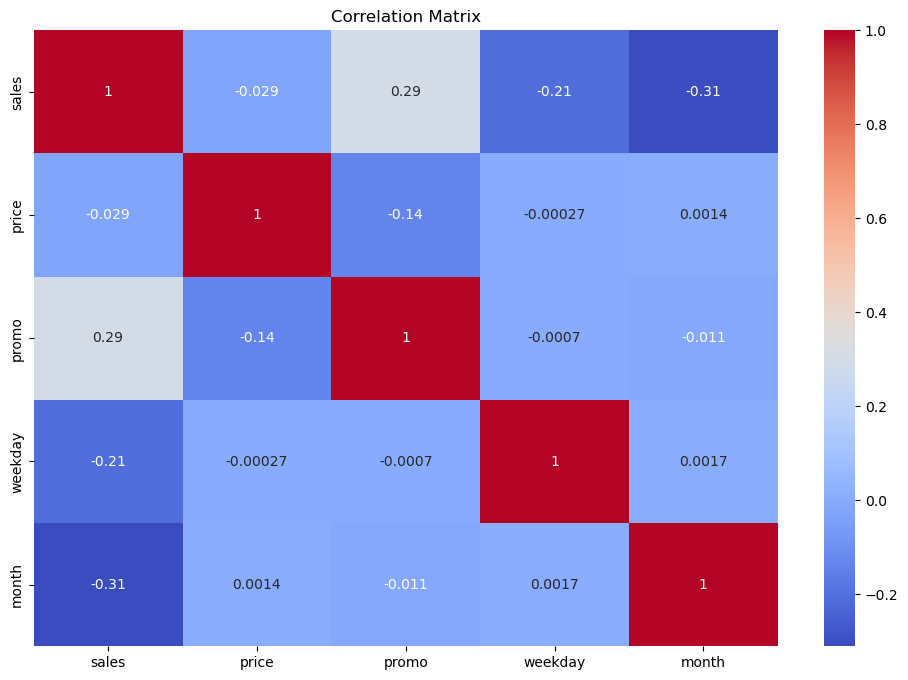

In [12]:
# correlation matrix
plt.figure(figsize=(12,8))

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

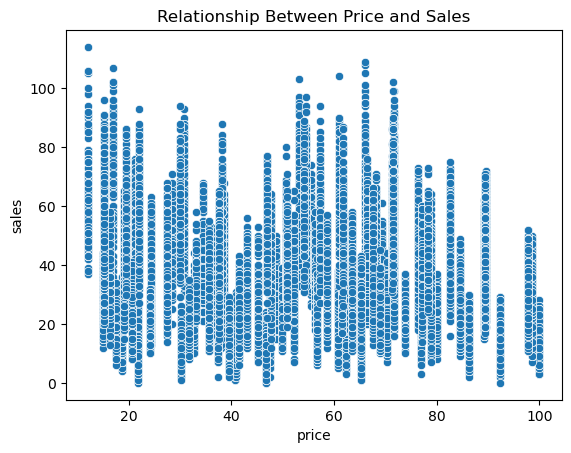

In [13]:
# scatterplot antar variabel
sns.scatterplot(data=df, x='price', y='sales')

plt.title('Relationship Between Price and Sales')

plt.show()

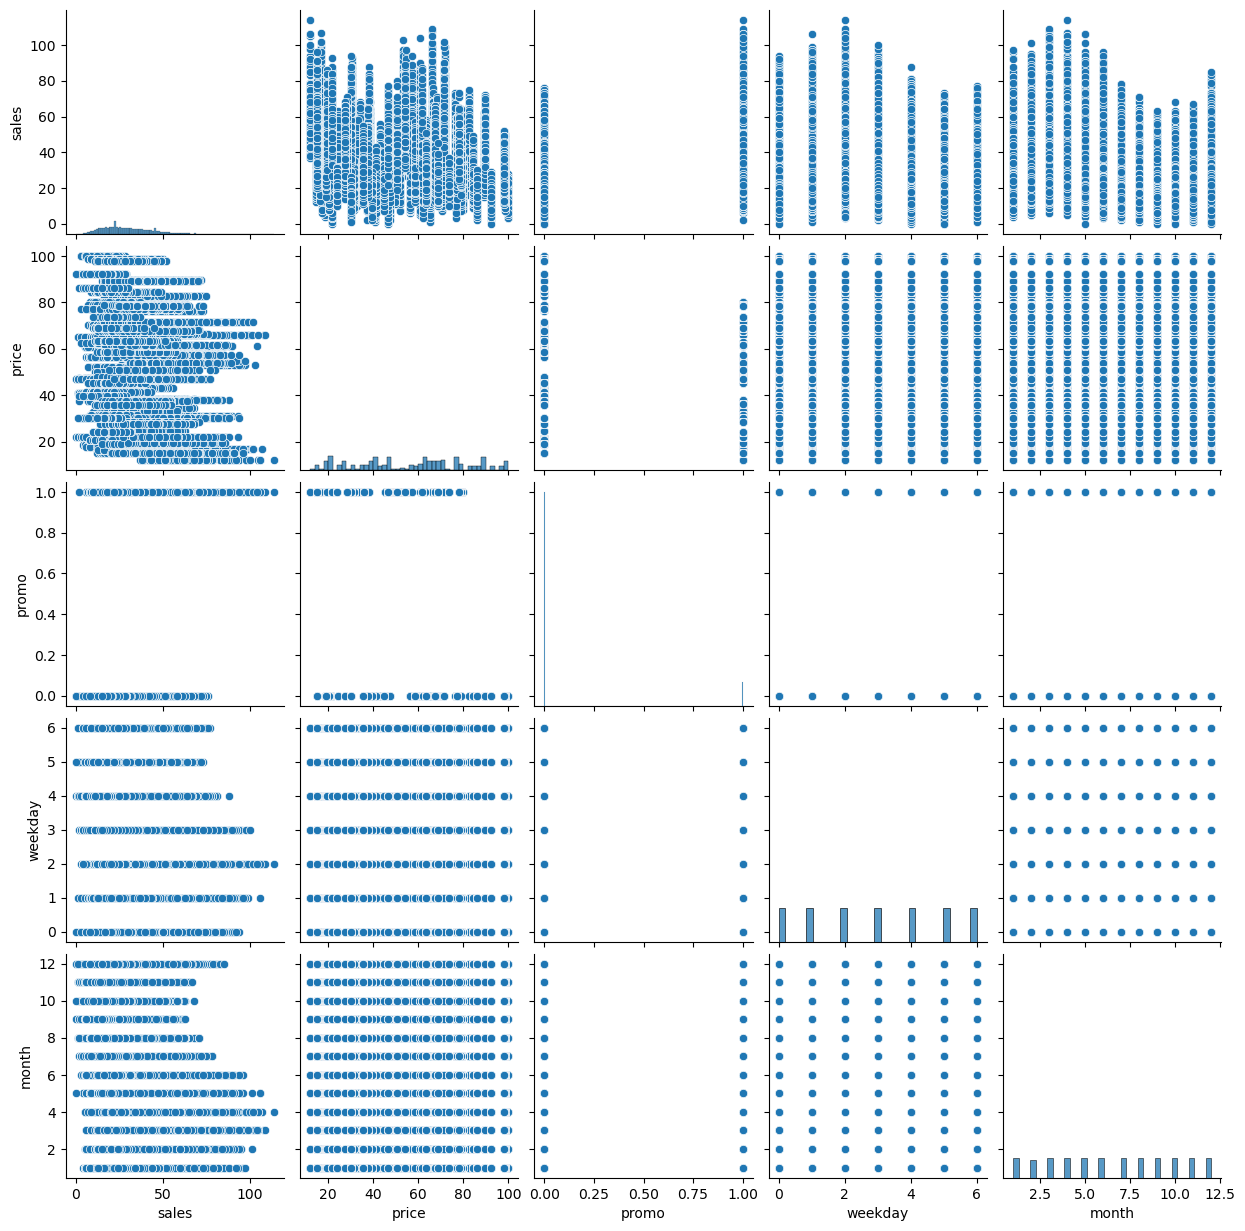

In [14]:
# pairplot numerical features
sns.pairplot(df[num_cols])

plt.show()

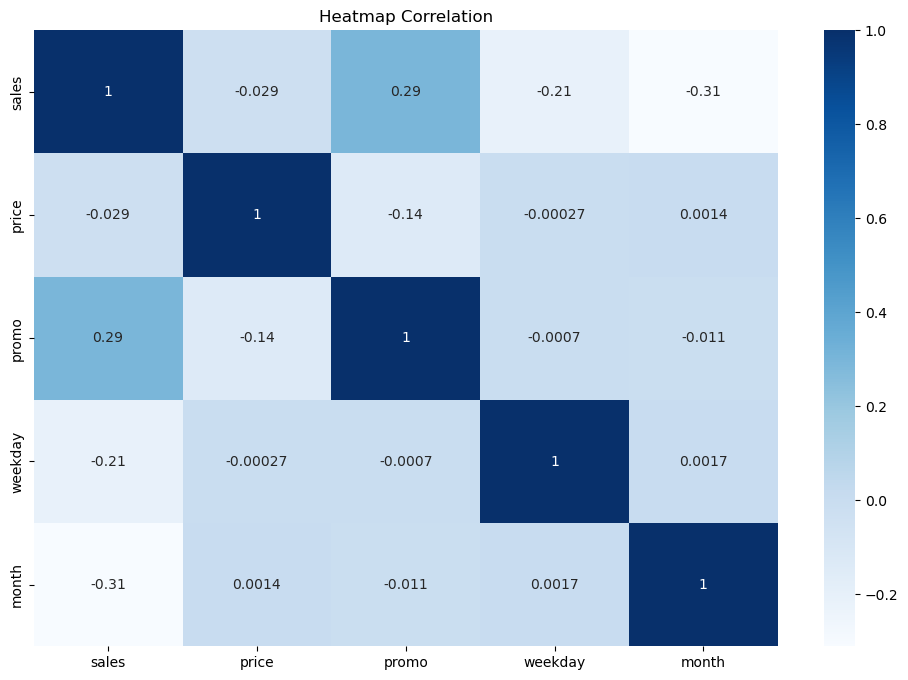

In [15]:
# heatmap correlation
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')

plt.title('Heatmap Correlation')

plt.show()

# 8. Outlier Analysis

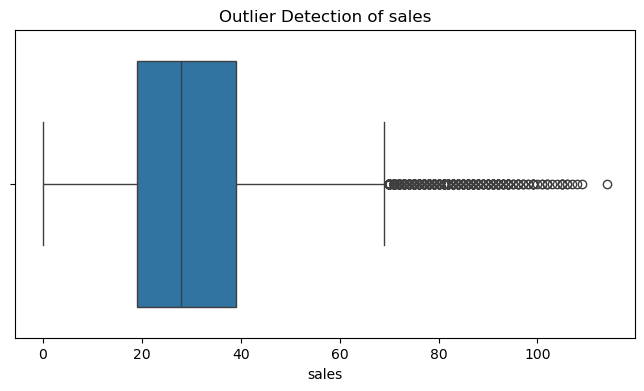

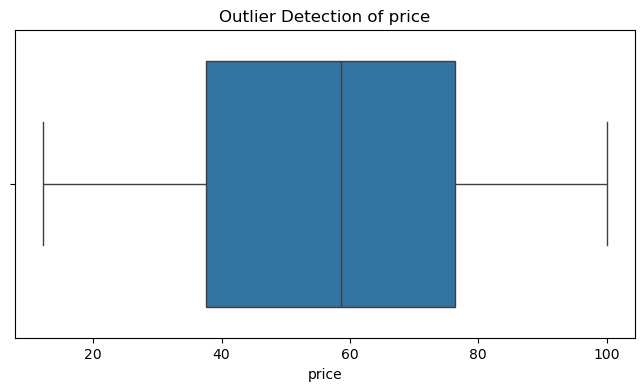

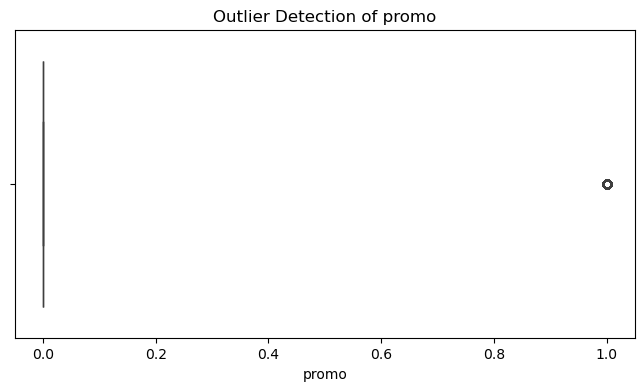

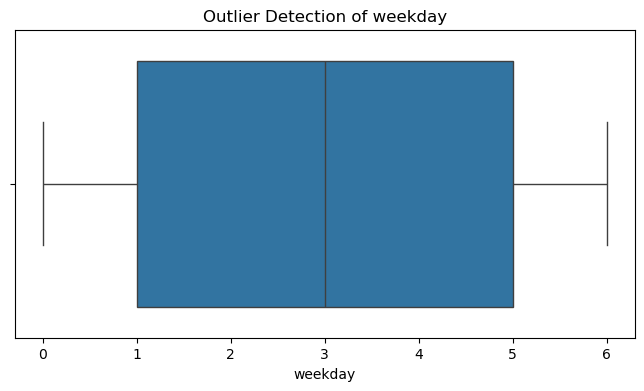

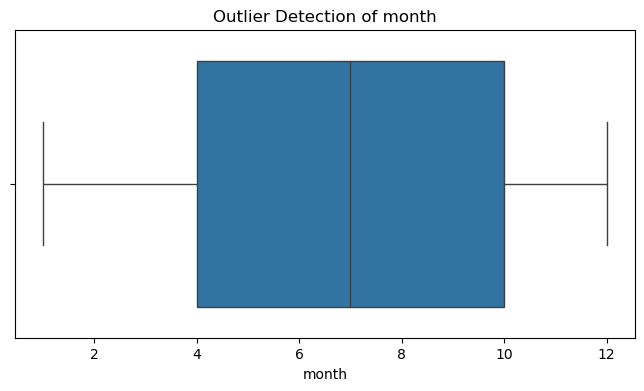

In [16]:
# visualisasi outlier
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Outlier Detection of {col}')
    
    plt.show()

# 9. Normality Test

In [17]:
# shapiro test
for col in num_cols:
    
    stat, p = shapiro(df[col].sample(500))
    
    print(f'{col}')
    print(f'Statistic : {stat}')
    print(f'P-value   : {p}')
    print('-'*50)

sales
Statistic : 0.9542403368870203
P-value   : 2.4834534010790707e-11
--------------------------------------------------
price
Statistic : 0.9577797618449986
P-value   : 8.94696207689232e-11
--------------------------------------------------
promo
Statistic : 0.38218908882100244
P-value   : 5.669997496059952e-38
--------------------------------------------------
weekday
Statistic : 0.9243710393472757
P-value   : 3.634773574147092e-15
--------------------------------------------------
month
Statistic : 0.9423189314682308
P-value   : 5.074293577236321e-13
--------------------------------------------------


Berdasarkan hasil exploratory data analysis (EDA), dataset memiliki beberapa karakteristik penting yang dapat digunakan pada tahap preprocessing dan modeling.

Hasil analisis menunjukkan bahwa:

- terdapat beberapa fitur dengan distribusi skewed,
- ditemukan outlier pada beberapa variabel numerik,
- beberapa variabel memiliki korelasi yang cukup kuat,
- distribusi kategori menunjukkan adanya ketidakseimbangan pada beberapa fitur.

Hasil EDA ini akan digunakan sebagai dasar pada tahap preprocessing dan feature engineering.